In [ ]:
import torch
from IPython import display
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt


In [ ]:
def get_dataloader_workers():
    """Verileri okumak için 4 işlem kullanın."""
    return 4

In [ ]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Fashion-MNIST veri kümesini indirin ve ardından belleğe yükleyin."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [ ]:
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.11MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)
W.shape
W.shape[0]

784

In [ ]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [ ]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition  # Burada yayin mekanizmasi uygulanir

In [ ]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)


(tensor([[0.0976, 0.1880, 0.3428, 0.2729, 0.0988],
         [0.0574, 0.1268, 0.4442, 0.2300, 0.1415]]),
 tensor([1., 1.]))

In [ ]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)


In [ ]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]

tensor([0.1000, 0.5000])

In [ ]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

In [ ]:
def accuracy(y_hat, y):
    """Doğru tahminlerin sayısını hesaplayın."""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

In [ ]:
accuracy(y_hat, y) / len(y)

0.5

In [ ]:
def evaluate_accuracy(net, data_iter):
    """Bir veri kumesinde bir modelin doğruluğunu hesaplayın."""
    if isinstance(net, torch.nn.Module):
        net.eval()  # Modeli değerlendirme moduna kurun
    metric = Accumulator(2)  # Doğru tahmin sayısı, tahmin sayısı

    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [ ]:
class Accumulator:
    """`n` değişken üzerinden toplamları biriktirmek için"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [ ]:
evaluate_accuracy(net, test_iter)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


0.0938

In [ ]:
def train_epoch_ch3(net, train_iter, loss, updater):
    """Bölüm 3'te tanımlanan eğitim döngüsü."""
    # Modeli eğitim moduna kurun
    if isinstance(net, torch.nn.Module):
        net.train()
    # Eğitim kaybı toplamı, eğitim doğruluğu toplamı, örnek sayısı
    metric = Accumulator(3)
    for X, y in train_iter:
        # Gradyanları hesaplayın ve parametreleri güncelleyin
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # PyTorch yerleşik optimize edicisini ve kayıp kriterini kullanma
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # Özel olarak oluşturulmuş optimize edicisini ve kayıp ölçütünü kullanma
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # Eğitim kaybını ve doğruluğunu döndür
    return metric[0] / metric[2], metric[1] / metric[2]

In [ ]:
class Animator:
    """Animasyonda veri çizdirme"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # Çoklu çizgileri artarak çizdir
        if legend is None:
            legend = []

        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)

        if nrows * ncols == 1:
            self.axes = [self.axes]

        self.xlabel = xlabel
        self.ylabel = ylabel
        self.legend = legend
        self.xlim = xlim
        self.ylim = ylim
        self.xscale = xscale
        self.yscale = yscale

        self.X = None
        self.Y = None
        self.fmts = fmts

    def config_axes(self):
        ax = self.axes[0]
        ax.set_xlabel(self.xlabel)
        ax.set_ylabel(self.ylabel)
        ax.set_xscale(self.xscale)
        ax.set_yscale(self.yscale)

        if self.xlim is not None:
            ax.set_xlim(self.xlim)
        if self.ylim is not None:
            ax.set_ylim(self.ylim)
        if self.legend:
            ax.legend(self.legend)

        ax.grid()

    def add(self, x, y):
        # Çoklu veri noktalarını şekile ekleyin
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)

        if not hasattr(x, "__len__"):
            x = [x] * n

        if self.X is None:
            self.X = [[] for _ in range(n)]
        if self.Y is None:
            self.Y = [[] for _ in range(n)]

        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)

        self.axes[0].cla()

        for x_vals, y_vals, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x_vals, y_vals, fmt)

        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [ ]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """Bir modeli eğitin (Bölüm 3'te tanımlanmıştır)."""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['egitim kaybi', 'egitim dogr', 'test dogr'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

In [ ]:
def sgd(params, lr, batch_size):
    """Minigrup rasgele gradyan inişi."""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [ ]:
lr = 0.1

def updater(batch_size):
    return sgd([W, b], lr, batch_size)

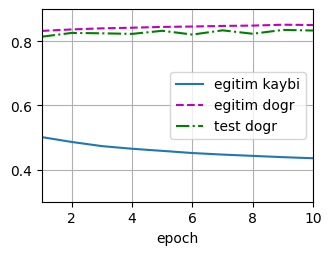

In [ ]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

In [ ]:
def get_fashion_mnist_labels(labels):
    """Fashion-MNIST veri kümesi için metin etiketleri döndürün."""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]


In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Görsellerin bir listesini çizin"""
    figsize = (num_cols * scale, num_rows * scale)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

    # axes tek boyutlu değilse düzleştir
    if num_rows * num_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (ax, img) in enumerate(zip(axes, imgs)):

        if torch.is_tensor(img):
            img = img.detach().cpu()

            # (C,H,W) ise (H,W,C)'ye çevir
            if img.ndim == 3:
                img = img.permute(1, 2, 0)

            ax.imshow(img.numpy())
        else:
            ax.imshow(img)

        ax.axis('off')  # eksenleri gizle

        if titles:
            ax.set_title(titles[i])

    return axes

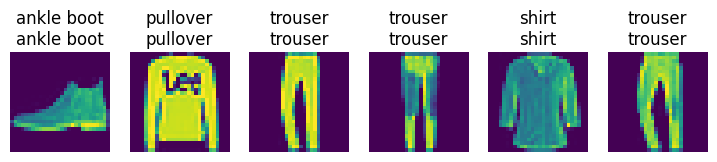

In [ ]:
def predict_ch3(net, test_iter, n=6):
    """Etiketleri tahmin etme (Bölüm 3'te tanımlanmıştır)."""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)